## 1. Setup

In [ ]:
import io, os, time, json, platform
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

from sklearn.model_selection import train_test_split, KFold, RandomizedSearchCV
from sklearn.compose import TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.feature_selection import SelectFromModel
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# the Task 2 pipeline (feature engineering, encoding, outlier capping, scaling) lives in this module
from uber_pipeline import (FeatureEngineer, build_preprocessor, build_pipeline, haversine_km,
                           RAW_COLUMNS, NUMERIC_COLS, CAT_COLS, PASSTHROUGH_COLS)

sns.set_theme(style='whitegrid')
print('scikit-learn', sklearn.__version__, '| pandas', pd.__version__, '| python', platform.python_version())

scikit-learn 1.8.0 | pandas 3.0.2 | python 3.12.3


## 2. Data: the same cleaning as Task 1 and Task 2


In [ ]:
DATA_PATH = next(p for p in ['final_internship_data.csv', '/content/final_internship_data.csv',
                             '/mnt/user-data/uploads/final_internship_data.csv'] if os.path.exists(p))
raw = pd.read_csv(DATA_PATH)
df = raw.copy()

df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
df = df.rename(columns={'day': 'day_of_month', 'weekday': 'day_of_week'})
df = df.drop(columns=['user_id', 'user_name', 'driver_name'])

coord_cols = ['pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude']
df[coord_cols] = np.degrees(df[coord_cols])                    # radians -> degrees (Task 1 finding)

df = df.dropna()
keep = (df['pickup_longitude'].between(-74.3, -73.7) & df['pickup_latitude'].between(40.5, 41.0) &
        df['dropoff_longitude'].between(-74.3, -73.7) & df['dropoff_latitude'].between(40.5, 41.0) &
        df['fare_amount'].between(2.5, 100) & df['passenger_count'].between(1, 6) & (df['distance'] >= 0.05))
df = df[keep]
df = df.drop_duplicates()
df = df[~df['key'].duplicated()].drop(columns=['key'])
print(f'Rows kept: {len(df):,} of {len(raw):,} ({len(df) / len(raw):.1%})   <- same as Task 1')

Rows kept: 479,944 of 500,000 (96.0%)   <- same as Task 1


In [ ]:
X = df[RAW_COLUMNS]
y = df['fare_amount']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Train: {len(X_train):,} rows   Test: {len(X_test):,} rows')

# sanity check: the datetime features the pipeline derives match the columns Task 1 / Task 2 used
when = pd.to_datetime(df['pickup_datetime'])
print('hour matches file     :', bool((when.dt.hour == df['hour']).all()))
print('weekday matches file  :', bool((when.dt.dayofweek == df['day_of_week']).all()))
print('year matches file     :', bool((when.dt.year == df['year']).all()))
print('distance column = haversine of the coordinates:',
      bool(np.allclose(df['distance'], haversine_km(df['pickup_latitude'], df['pickup_longitude'],
                                                    df['dropoff_latitude'], df['dropoff_longitude']))))

Train: 383,955 rows   Test: 95,989 rows
hour matches file     : True
weekday matches file  : True
year matches file     : True
distance column = haversine of the coordinates: True


## 3. Re-check of Task 2: why were the two models so similar?



In [ ]:
def metrics(y_true, y_pred):
    return {'MAE': mean_absolute_error(y_true, y_pred),
            'RMSE': mean_squared_error(y_true, y_pred) ** 0.5,
            'R2': r2_score(y_true, y_pred)}

def task2_style(model, lasso_select=True, log_target=True):
    # Task 2 setup: features -> preprocess -> Lasso selector -> model, wrapped in log1p/expm1 target transform
    steps = [('features', FeatureEngineer()), ('preprocess', build_preprocessor())]
    if lasso_select:
        steps.append(('select', SelectFromModel(Lasso(alpha=0.01, max_iter=5000))))
    steps.append(('model', model))
    pipe = Pipeline(steps)
    return TransformedTargetRegressor(regressor=pipe, func=np.log1p, inverse_func=np.expm1) if log_target else pipe

variants = {
    'Task 2 baseline: Linear Regression (log target + Lasso)': task2_style(LinearRegression()),
    'Task 2 tuned: Ridge alpha=1 (log target + Lasso)':         task2_style(Ridge(alpha=1)),
    'Task 2 tuned: Ridge alpha=1000 (log target + Lasso)':      task2_style(Ridge(alpha=1000)),
    'Fixed: Linear Regression (dollar target, no Lasso)':       task2_style(LinearRegression(), False, False),
    'Fixed: Ridge alpha=1 (dollar target, no Lasso)':           task2_style(Ridge(alpha=1), False, False),
}
rows, t2_preds = {}, {}
for name, m in variants.items():
    m.fit(X_train, y_train)
    t2_preds[name] = m.predict(X_test)
    rows[name] = metrics(y_test, t2_preds[name])
task2_check = pd.DataFrame(rows).T.round(3)
task2_check

,MAE,RMSE,R2
Task 2 baseline: Linear Regression (log target + Lasso),2.945,6.615,0.483
Task 2 tuned: Ridge alpha=1 (log target + Lasso),2.945,6.615,0.483
Task 2 tuned: Ridge alpha=1000 (log target + Lasso),2.939,6.558,0.492
"Fixed: Linear Regression (dollar target, no Lasso)",2.095,3.801,0.829
"Fixed: Ridge alpha=1 (dollar target, no Lasso)",2.095,3.801,0.829


In [ ]:
names = list(variants)
gap = np.abs(t2_preds[names[0]] - t2_preds[names[1]]).max()
print(f'Largest difference between the Task 2 baseline and tuned predictions on {len(y_test):,} test rides: ${gap:.4f}')

# which features did the Task 2 Lasso step keep?
fitted_t2 = variants[names[0]].regressor_
feat_names = fitted_t2.named_steps['preprocess'].get_feature_names_out()
kept = fitted_t2.named_steps['select'].get_support()
print('Kept   :', [n.split('__')[1] for n in feat_names[kept]])
print('Dropped:', [n.split('__')[1] for n in feat_names[~kept]])

Largest difference between the Task 2 baseline and tuned predictions on 95,989 test rides: $0.0018
Kept   : ['distance', 'jfk_km', 'year', 'hour_sin', 'hour_cos']
Dropped: ['passenger_count', 'car_condition_ord', 'traffic_condition_ord', 'weather_rainy', 'weather_stormy', 'weather_sunny', 'weather_windy', 'is_weekend', 'is_near_airport']


## 4. Part A: model comparison





In [ ]:
# --- tune Gradient Boosting on the TRAINING data only (the test set is never touched here) ---
gb_search = RandomizedSearchCV(
    build_pipeline(HistGradientBoostingRegressor(early_stopping=True, validation_fraction=0.1,
                                                 n_iter_no_change=15, random_state=42)),
    param_distributions={
        'model__learning_rate':    [0.03, 0.05, 0.08, 0.1, 0.15],
        'model__max_iter':         [200, 300, 400],
        'model__max_leaf_nodes':   [15, 31, 63],
        'model__min_samples_leaf': [20, 40, 80],
        'model__l2_regularization': [0.0, 0.5, 1.0, 5.0],
    },
    n_iter=6, cv=KFold(n_splits=3, shuffle=True, random_state=42),
    scoring='neg_mean_absolute_error', random_state=42, n_jobs=1)
gb_search.fit(X_train, y_train)
print('Best gradient-boosting settings:', gb_search.best_params_)
print(f'Best 3-fold CV MAE on the training data: ${-gb_search.best_score_:.3f}')

Best gradient-boosting settings: {'model__min_samples_leaf': 80, 'model__max_leaf_nodes': 31, 'model__max_iter': 400, 'model__learning_rate': 0.08, 'model__l2_regularization': 0.0}
Best 3-fold CV MAE on the training data: $1.889


In [ ]:
models = {
    'Linear Regression': build_pipeline(LinearRegression()),
    'Ridge (alpha=1)':   build_pipeline(Ridge(alpha=1.0)),
    'Decision Tree':     build_pipeline(DecisionTreeRegressor(max_depth=12, min_samples_leaf=20, random_state=42)),
    'Random Forest':     build_pipeline(RandomForestRegressor(n_estimators=60, min_samples_leaf=10,
                                                              max_features=0.6, n_jobs=-1, random_state=42)),
    'Gradient Boosting': gb_search.best_estimator_,         # already fitted on the full training set by the search
}

fitted, rows = {}, []
for name, pipe in models.items():
    t = time.time()
    if name != 'Gradient Boosting':
        pipe.fit(X_train, y_train)
        fit_s = time.time() - t
    else:
        fit_s = gb_search.refit_time_                        # time of the final fit (the search itself took longer)
    t = time.time(); test_pred = pipe.predict(X_test); pred_s = time.time() - t
    train_pred = pipe.predict(X_train)
    buf = io.BytesIO(); joblib.dump(pipe, buf)
    m = metrics(y_test, test_pred)
    rows.append({'Model': name, 'MAE ($)': m['MAE'], 'RMSE ($)': m['RMSE'], 'R2': m['R2'],
                 'Train MAE ($)': mean_absolute_error(y_train, train_pred),
                 'Fit time (s)': fit_s, 'Predict 96k rides (s)': pred_s,
                 'File size (MB)': buf.getbuffer().nbytes / 1e6})
    fitted[name] = pipe

results = pd.DataFrame(rows).set_index('Model').round(3)
results.sort_values('MAE ($)')

,MAE ($),RMSE ($),R2,Train MAE ($),Fit time (s),Predict 96k rides (s),File size (MB)
Model,,,,,,,
Gradient Boosting,1.875,3.493,0.856,1.871,5.449,0.781,0.597
Random Forest,1.893,3.508,0.855,1.626,73.541,1.527,162.278
Decision Tree,1.936,3.601,0.847,1.875,2.661,0.134,0.286
Ridge (alpha=1),2.095,3.801,0.829,2.108,0.653,0.123,0.004
Linear Regression,2.095,3.801,0.829,2.108,0.729,0.172,0.004


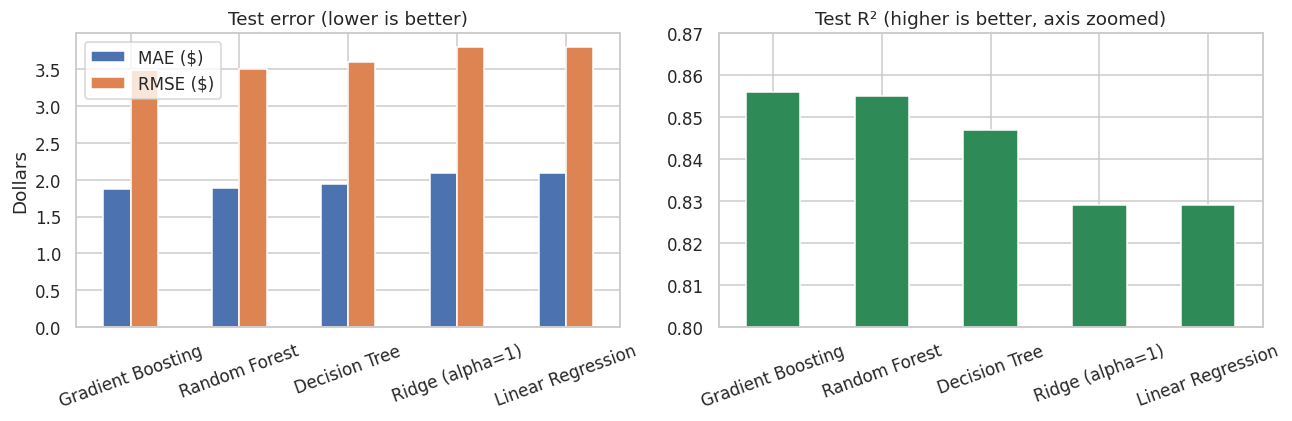

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
order = results.sort_values('MAE ($)').index
results.loc[order, ['MAE ($)', 'RMSE ($)']].plot.bar(ax=axes[0], rot=20)
axes[0].set_title('Test error (lower is better)'); axes[0].set_ylabel('Dollars'); axes[0].set_xlabel('')
results.loc[order, 'R2'].plot.bar(ax=axes[1], rot=20, color='seagreen')
axes[1].set_ylim(0.8, 0.87); axes[1].set_title('Test R² (higher is better, axis zoomed)'); axes[1].set_xlabel('')
plt.tight_layout(); plt.show()

**Reading the table.** MAE is the average dollar error per ride, RMSE is also in dollars but punishes big misses harder, and R² is the share of the fare variation the model explains. *Train MAE* next to test MAE shows overfitting: a model whose training error is far below its test error has memorised the training rides.

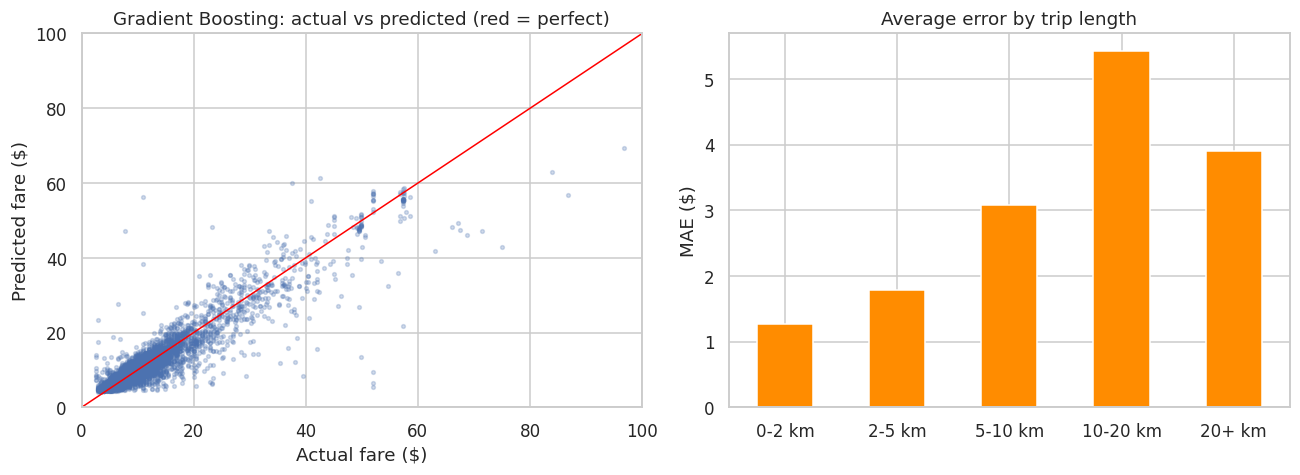

In [ ]:
best_name = results['MAE ($)'].idxmin()
best_pipe = fitted[best_name]
pred = best_pipe.predict(X_test)

# actual vs predicted, and where the errors are largest
idx = np.random.RandomState(42).choice(len(y_test), 6000, replace=False)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(y_test.values[idx], pred[idx], s=6, alpha=0.25)
axes[0].plot([0, 100], [0, 100], color='red', lw=1)
axes[0].set_xlim(0, 100); axes[0].set_ylim(0, 100)
axes[0].set_xlabel('Actual fare ($)'); axes[0].set_ylabel('Predicted fare ($)')
axes[0].set_title(f'{best_name}: actual vs predicted (red = perfect)')

trip_km = haversine_km(X_test['pickup_latitude'], X_test['pickup_longitude'],
                       X_test['dropoff_latitude'], X_test['dropoff_longitude'])
err = pd.DataFrame({'abs_err': np.abs(y_test.values - pred),
                    'band': pd.cut(trip_km.values, [0, 2, 5, 10, 20, 100],
                                   labels=['0-2 km', '2-5 km', '5-10 km', '10-20 km', '20+ km'])})
err.groupby('band', observed=True)['abs_err'].mean().plot.bar(ax=axes[1], rot=0, color='darkorange')
axes[1].set_title('Average error by trip length'); axes[1].set_ylabel('MAE ($)'); axes[1].set_xlabel('')
plt.tight_layout(); plt.show()

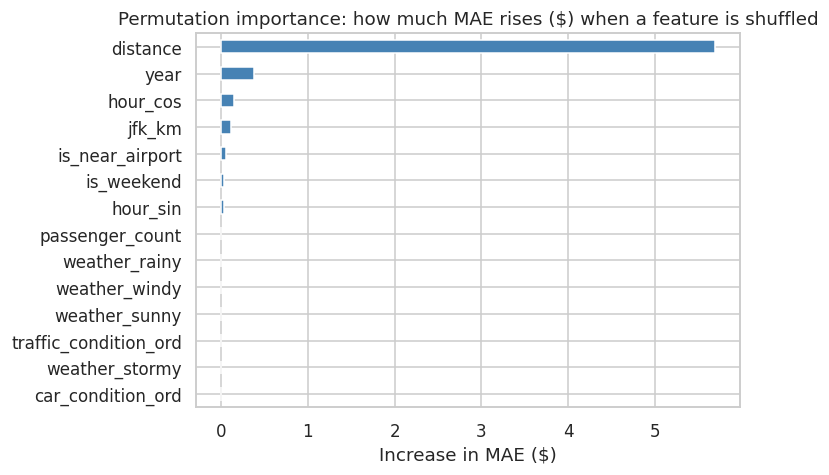

In [ ]:
# what does the chosen model rely on?  (permutation importance on 20,000 test rides, measured on the model's input features)
sample_idx = X_test.sample(20000, random_state=42).index
Xp = best_pipe.named_steps['preprocess'].transform(best_pipe.named_steps['features'].transform(X_test.loc[sample_idx]))
perm = permutation_importance(best_pipe.named_steps['model'], Xp, y_test.loc[sample_idx], n_repeats=3,
                              random_state=42, scoring='neg_mean_absolute_error')
imp = pd.Series(perm.importances_mean, index=[n.split('__')[1] for n in best_pipe.named_steps['preprocess'].get_feature_names_out()])
imp = imp.sort_values()
imp.plot.barh(figsize=(7, 4.5), color='steelblue')
plt.title('Permutation importance: how much MAE rises ($) when a feature is shuffled'); plt.xlabel('Increase in MAE ($)')
plt.tight_layout(); plt.show()

## 5. Which model to deploy, and why

**Chosen model: Gradient Boosting.** On the held-out test set it has the lowest error of all five models (MAE 1.88, RMSE 3.49, R² 0.856), ahead of Random Forest (MAE $1.89) and clearly ahead of Linear Regression (MAE 2.10, R² 0.829), because fares are not a straight line in the inputs.

## 6. Part B: save the model and its preprocessing



In [ ]:
joblib.dump(best_pipe, 'uber_fare_model.pkl')                                    # full pipeline = preprocessing + model
joblib.dump(Pipeline(best_pipe.steps[:-1]), 'uber_fare_preprocessor.pkl')        # the fitted preprocessing steps on their own
meta = {'model': best_name,
        'test_metrics': {k: round(float(v), 4) for k, v in metrics(y_test, pred).items()},
        'trained_rows': int(len(X_train)), 'sklearn_version': sklearn.__version__,
        'input_columns': RAW_COLUMNS}
json.dump(meta, open('model_metadata.json', 'w'), indent=2)

# prove the saved file works: reload it and compare against the in-memory model
reloaded = joblib.load('uber_fare_model.pkl')
same = np.allclose(reloaded.predict(X_test.head(2000)), best_pipe.predict(X_test.head(2000)))
print('Saved:', [f for f in os.listdir('.') if f.startswith('uber_fare') or f == 'model_metadata.json'])
print('Reloaded model gives identical predictions:', same)

Saved: ['uber_fare_preprocessor.pkl', 'uber_fare_model.pkl', 'model_metadata.json']
Reloaded model gives identical predictions: True


## 7. Sanity checks you can verify

Four trips typed in as **raw** values, exactly like the web form. To check them without trusting the model.

In [ ]:
trips = pd.DataFrame([
    # name,                           pick lat, pick lon,  drop lat, drop lon,  pax, datetime,              weather, traffic,            car
    ('Times Sq -> Central Park S',   40.7580, -73.9855,   40.7648, -73.9730,   1, '2014-06-17 18:30:00', 'sunny',  'Flow Traffic',      'Good'),
    ('Midtown -> Brooklyn Bridge',   40.7527, -73.9772,   40.7061, -73.9969,   2, '2014-06-17 09:00:00', 'cloudy', 'Dense Traffic',     'Very Good'),
    ('Midtown -> JFK Airport',       40.7527, -73.9772,   40.6413, -73.7781,   1, '2014-06-17 14:00:00', 'sunny',  'Flow Traffic',      'Excellent'),
    ('JFK Airport -> Midtown',       40.6413, -73.7781,   40.7527, -73.9772,   1, '2014-06-17 14:00:00', 'sunny',  'Flow Traffic',      'Excellent'),
], columns=['name'] + RAW_COLUMNS[:4] + ['passenger_count', 'pickup_datetime', 'weather', 'traffic_condition', 'car_condition'])

out = trips[['name']].copy()
out['distance_km'] = haversine_km(trips['pickup_latitude'], trips['pickup_longitude'],
                                  trips['dropoff_latitude'], trips['dropoff_longitude']).round(2)

def similar_rides(km, year, tol=0.10):
    s = df[df['distance'].between(km * (1 - tol), km * (1 + tol)) & (df['year'] == year)]['fare_amount']
    return len(s), s.median(), s.quantile(0.25), s.quantile(0.75)

ref = [similar_rides(km, 2014) for km in out['distance_km']]
out['similar_rides_in_data'] = [r[0] for r in ref]
out['typical_fare_$ (median)'] = [round(r[1], 2) for r in ref]
out['middle_50%_range_$'] = [f'{r[2]:.1f} - {r[3]:.1f}' for r in ref]
out['model_prediction_$'] = best_pipe.predict(trips[RAW_COLUMNS]).round(2)
out

,name,distance_km,similar_rides_in_data,typical_fare_$ (median),middle_50%_range_$,model_prediction_$
0,Times Sq -> Central Park S,1.30,6208,6.50,6.0 - 8.0,7.47
1,Midtown -> Brooklyn Bridge,5.44,3700,17.00,15.0 - 19.5,19.48
2,Midtown -> JFK Airport,20.86,1280,57.33,54.9 - 57.3,58.08
3,JFK Airport -> Midtown,20.86,1280,57.33,54.9 - 57.3,56.51


## 8. Parts C and D: the Flask app and its tests

* `app.py` loads `uber_fare_model.pkl` **once at start-up**, validates the form (`validate_trip` in `uber_pipeline.py`), turns the values into a one-row DataFrame and calls `model.predict`. Because the saved object *is* the Task 2 pipeline, the user's raw values go through the same feature engineering, encoding, outlier cap and scaling that the training data did.
* `templates/index.html` is the form + result page. Required fields, number/date inputs with min/max, and sensible defaults stop most bad input in the browser; the server re-checks everything and shows a clear message for anything that slips through.
